# ⚖️ Notebook 06B: Advanced Threshold Tuning & Fairness (Version A vs B)

> **Mục tiêu**: 
> 1. Xử lý vấn đề False Positives (FP) bằng Threshold Tuning dựa trên Business Cost (Chi phí 1:50).
> 2. Phân tích nhạy cảm (Sensitivity Analysis) với các kịch bản chi phí khác nhau.
> 3. Đánh giá "Fairness through unawareness" bằng cách loại bỏ `customer_age` và `income` khỏi tập train.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_recall_curve

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_processed_data
from src.imbalance import calculate_scale_pos_weight
from src.models.xgboost_model import build_xgboost_model
from src.evaluation import evaluate_model

# Load dữ liệu
print("Loading Parquet data...")
df_train = load_processed_data("train.parquet")
df_test = load_processed_data("test.parquet")

X_train_A = df_train.drop(columns=['fraud_bool', 'month'], errors='ignore')
y_train = df_train['fraud_bool'].values
X_test_A = df_test.drop(columns=['fraud_bool', 'month'], errors='ignore')
y_test = df_test['fraud_bool'].values

spw = calculate_scale_pos_weight(y_train)


Loading Parquet data...


## 1. Tối ưu Threshold dựa trên Business Cost
Ngân hàng giả định:
- **COST_FALSE_POSITIVE = 1**: chi phí nhân viên review tay oan 1 case.
- **COST_FALSE_NEGATIVE = 50**: chi phí khi bỏ lọt 1 case fraud thật.


In [2]:
print("Training Version A (Full Features)...")
model_A = build_xgboost_model(scale_pos_weight=spw)
model_A.fit(X_train_A, y_train)
y_pred_proba_A = model_A.predict_proba(X_test_A)[:, 1]

COST_FALSE_POSITIVE = 1
COST_FALSE_NEGATIVE = 50

y_scores = y_pred_proba_A
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_scores)

costs = []
for thresh in thresholds_pr:
    y_pred = (y_scores >= thresh).astype(int)
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    total_cost = fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE
    costs.append(total_cost)

best_idx = np.argmin(costs)
best_threshold = thresholds_pr[best_idx]
print(f"Threshold tối ưu thật sự (Cost 1:50): {best_threshold:.3f}")
print(f"Tổng cost tại threshold này: {costs[best_idx]:,}")


Training Version A (Full Features)...
Threshold tối ưu thật sự (Cost 1:50): 0.480
Tổng cost tại threshold này: 63,983


## 2. Sensitivity Analysis (Đánh đổi theo khẩu vị rủi ro)
Quét các tỷ lệ FN:FP (10:1, 50:1, 100:1) để vẽ biểu đồ sự dịch chuyển của Threshold tối ưu.


Tỷ lệ FN:FP = 10:1 → Threshold tối ưu = 0.83
Tỷ lệ FN:FP = 50:1 → Threshold tối ưu = 0.48
Tỷ lệ FN:FP = 100:1 → Threshold tối ưu = 0.33


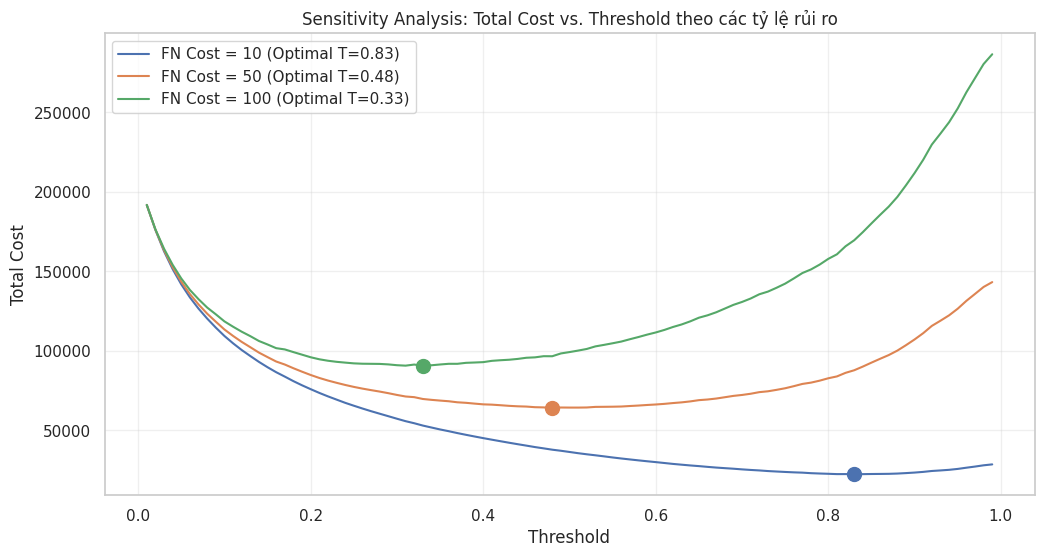

In [3]:
cost_ratios = [10, 50, 100]
thresholds_full = np.arange(0.01, 1.00, 0.01)

plt.figure(figsize=(12, 6))

for fn_cost in cost_ratios:
    costs_sens = []
    for t in thresholds_full:
        y_pred = (y_scores >= t).astype(int)
        fp = ((y_pred == 1) & (y_test == 0)).sum()
        fn = ((y_pred == 0) & (y_test == 1)).sum()
        costs_sens.append(fp * 1 + fn * fn_cost)
        
    best_t = thresholds_full[np.argmin(costs_sens)]
    print(f"Tỷ lệ FN:FP = {fn_cost}:1 → Threshold tối ưu = {best_t:.2f}")
    
    plt.plot(thresholds_full, costs_sens, label=f'FN Cost = {fn_cost} (Optimal T={best_t:.2f})')
    plt.scatter(best_t, min(costs_sens), s=100, zorder=5)

plt.xlabel('Threshold')
plt.ylabel('Total Cost')
plt.title('Sensitivity Analysis: Total Cost vs. Threshold theo các tỷ lệ rủi ro')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Fairness Through Unawareness (Version B)
Loại bỏ các thuộc tính nhạy cảm: `customer_age`, `income` khỏi tập Train/Test để xem mô hình bị giảm hiệu năng dự đoán bao nhiêu khi ta cố gắng làm nó "mù" với các yếu tố dễ gây thiên vị.


In [4]:
sensitive_cols = ['customer_age', 'income']

X_train_B = X_train_A.drop(columns=sensitive_cols, errors='ignore')
X_test_B = X_test_A.drop(columns=sensitive_cols, errors='ignore')

print(f"Version A Features: {X_train_A.shape[1]}")
print(f"Version B Features: {X_train_B.shape[1]} (Đã bỏ {sensitive_cols})")

print("\nTraining Version B (Unaware)...")
model_B = build_xgboost_model(scale_pos_weight=spw)
model_B.fit(X_train_B, y_train)
y_pred_proba_B = model_B.predict_proba(X_test_B)[:, 1]

metrics_A = evaluate_model(y_test, y_pred_proba_A, threshold=best_threshold)
metrics_B = evaluate_model(y_test, y_pred_proba_B, threshold=best_threshold)

df_compare = pd.DataFrame({'Version A (Full)': metrics_A, 'Version B (Unaware)': metrics_B}).T
display(df_compare[['AUROC', 'PR-AUC', 'Recall', 'False Positives']])


Version A Features: 33
Version B Features: 31 (Đã bỏ ['customer_age', 'income'])

Training Version B (Unaware)...


,AUROC,PR-AUC,Recall,False Positives
Version A (Full),0.889509,0.183216,0.773454,31383.0
Version B (Unaware),0.884152,0.169559,0.751216,31204.0
